In [1]:
from transformers import pipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Cargando modelo FinBERT...")
finbert = pipeline(
    "text-classification",
    model="ProsusAI/finbert",
    return_all_scores=True
)
print("Modelo cargado.")

# Prueba rápida
test_headlines = [
    "Fed raises interest rates by 50 basis points amid inflation concerns",
    "ECB signals dovish stance as eurozone growth slows",
    "EUR/USD surges after strong German manufacturing data"
]

for headline in test_headlines:
    resultado = finbert(headline)[0]
    scores = {r['label']: round(r['score'], 3) for r in resultado}
    sentimiento = max(resultado, key=lambda x: x['score'])['label']
    print(f"\n{headline[:60]}...")
    print(f"  → {sentimiento} | {scores}")

Cargando modelo FinBERT...


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Modelo cargado.


TypeError: string indices must be integers, not 'str'

In [2]:
 # Prueba con formato correcto
test_headlines = [
    "Fed raises interest rates by 50 basis points amid inflation concerns",
    "ECB signals dovish stance as eurozone growth slows",
    "EUR/USD surges after strong German manufacturing data"
]

for headline in test_headlines:
    resultado = finbert(headline)
    # resultado es una lista de dicts directamente
    scores = {r['label']: round(r['score'], 3) for r in resultado}
    sentimiento = max(resultado, key=lambda x: x['score'])['label']
    print(f"\n{headline[:60]}...")
    print(f"  → {sentimiento} | {scores}")


Fed raises interest rates by 50 basis points amid inflation ...
  → negative | {'negative': 0.455}

ECB signals dovish stance as eurozone growth slows...
  → negative | {'negative': 0.944}

EUR/USD surges after strong German manufacturing data...
  → positive | {'positive': 0.919}


In [3]:
def calcular_sentimiento(titulares, pesos=None):
    """
    Calcula score de sentimiento agregado para una lista de titulares.
    Retorna score entre -1 (muy bearish) y +1 (muy bullish).
    """
    if not titulares:
        return 0.0, 0.0
    
    if pesos is None:
        pesos = [1.0] * len(titulares)
    
    scores = []
    for titular in titulares:
        resultado = finbert(titular[:512])  # FinBERT max 512 tokens
        score_dict = {r['label']: r['score'] for r in resultado}
        
        # Score neto: positivo - negativo
        score_neto = score_dict.get('positive', 0) - score_dict.get('negative', 0)
        scores.append(score_neto)
    
    # Score ponderado
    scores = np.array(scores)
    pesos = np.array(pesos)
    score_final = np.average(scores, weights=pesos)
    incertidumbre = np.std(scores)
    
    return round(score_final, 4), round(incertidumbre, 4)

# Test con titulares mixtos
titulares_prueba = [
    "Fed raises interest rates by 50 basis points amid inflation concerns",
    "ECB signals dovish stance as eurozone growth slows",
    "EUR/USD surges after strong German manufacturing data",
    "US economy adds fewer jobs than expected in March",
    "Eurozone inflation falls to 2.1 percent in February"
]

score, incertidumbre = calcular_sentimiento(titulares_prueba)
print(f"Score agregado: {score}")
print(f"Incertidumbre: {incertidumbre}")
print(f"Interpretación: {'Bullish EUR/USD' if score > 0.1 else 'Bearish EUR/USD' if score < -0.1 else 'Neutral'}")

Score agregado: -0.476
Incertidumbre: 0.7232
Interpretación: Bearish EUR/USD


Sentimiento simulado agregado al dataset:
               Close   returns  regime  sentiment_score  sentiment_uncertainty
Date                                                                          
2026-03-23  1.156016 -0.001504       1          -0.4152                 0.4271
2026-03-24  1.160712  0.004054       1          -0.4731                 0.5556
2026-03-25  1.161467  0.000650       1           0.2564                 0.2351
2026-03-26  1.156150 -0.004589       1          -0.2028                 0.2036
2026-03-27  1.153509 -0.002287       1          -0.1370                 0.0955
2026-03-30  1.149201 -0.003742       1          -0.3051                 0.2343
2026-03-31  1.146000 -0.002789       1          -0.1367                 0.0779
2026-04-01  1.157421  0.009916       1           0.5021                 0.4796
2026-04-02  1.159057  0.001413       1           0.2976                 0.2406
2026-04-03  1.152871 -0.005352       1           0.2985                 0.2587


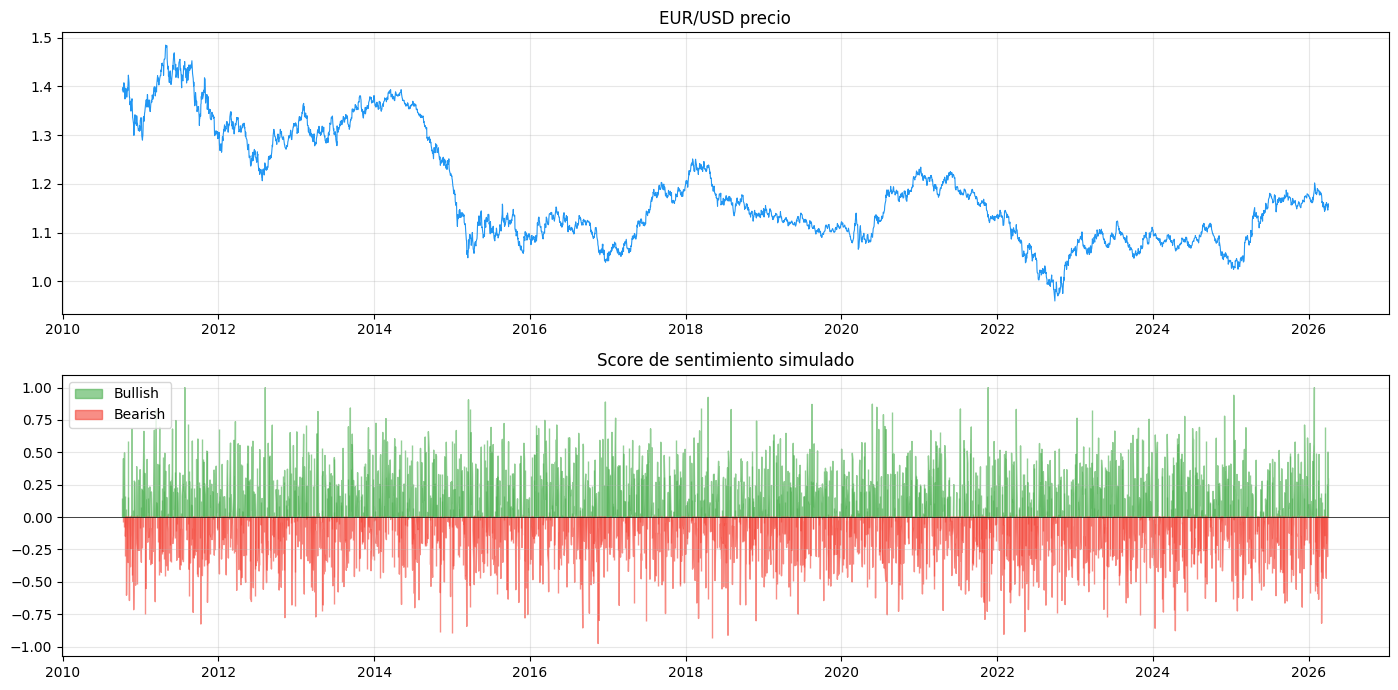

In [4]:
# Simulación de sentimiento diario
# En producción esto vendría de NewsAPI o RSS en tiempo real
np.random.seed(42)

daily = pd.read_csv("../data/processed/eurusd_con_regimen.csv",
                    index_col=0, parse_dates=True)

# Simular scores de sentimiento correlacionados con retornos reales
# (en producción serían scores reales de noticias)
noise = np.random.normal(0, 0.3, len(daily))
sentiment_base = daily['returns'].rolling(3).mean().fillna(0)
daily['sentiment_score'] = (sentiment_base * 20 + noise).clip(-1, 1).round(4)
daily['sentiment_uncertainty'] = np.abs(noise).clip(0, 1).round(4)

print("Sentimiento simulado agregado al dataset:")
print(daily[['Close', 'returns', 'regime', 
             'sentiment_score', 'sentiment_uncertainty']].tail(10))

# Visualizar
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(daily.index, daily['Close'], color='#2196F3', linewidth=0.8)
axes[0].set_title('EUR/USD precio', fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].fill_between(daily.index, daily['sentiment_score'],
                     where=daily['sentiment_score'] > 0,
                     color='#4CAF50', alpha=0.6, label='Bullish')
axes[1].fill_between(daily.index, daily['sentiment_score'],
                     where=daily['sentiment_score'] < 0,
                     color='#F44336', alpha=0.6, label='Bearish')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('Score de sentimiento simulado', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/07_sentimiento_finbert.png', dpi=150)
plt.show()

In [5]:
# Guardar dataset con sentimiento
daily.to_csv("../data/processed/eurusd_con_sentimiento.csv")
print(f"Dataset guardado: {daily.shape}")
print(f"Columnas finales: {daily.columns.tolist()}")

Dataset guardado: (4031, 40)
Columnas finales: ['Close', 'High', 'Low', 'Open', 'Volume', 'returns', 'volatility_20', 'volatility_60', 'rsi_14', 'atr_14', 'bb_mid', 'bb_std', 'bb_upper', 'bb_lower', 'bb_width', 'bb_position', 'sma_20', 'sma_50', 'sma_200', 'ema_12', 'ema_26', 'macd', 'macd_signal', 'macd_hist', 'momentum_5', 'momentum_10', 'momentum_20', 'high_20', 'low_20', 'price_position', 'trend_20_50', 'trend_50_200', 'return_lag_1', 'return_lag_2', 'return_lag_3', 'return_lag_5', 'return_lag_10', 'regime', 'sentiment_score', 'sentiment_uncertainty']
